# 04 - Feature Relationships

**Milestone 1 — Part 4.A**: Investigate correlations, F-statistics, and feature selection.

## Objectives
- Compute pairwise correlation matrix and heatmap
- Compute F-statistic (f_regression) for all features vs target
- Run forward and backward sequential feature selection
- Identify strongly correlated feature pairs

## Expected Outcomes
| Deliverable | Description |
|---|---|
| Correlation heatmap | Visual of pairwise correlations |
| F-statistic bar chart | Feature importance ranking via f_regression |
| Forward selection result | Top-k features chosen by forward SFS |
| Backward selection result | Top-k features chosen by backward SFS |
| Comparison notes | Agreement/disagreement across methods |

---

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_regression, SelectKBest, SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TARGET = "taxvaluedollarcnt"

df = pd.read_csv("zillow_cleaned.csv")
print(f"Shape: {df.shape}")

Shape: (75894, 29)


## 1. Correlation Matrix

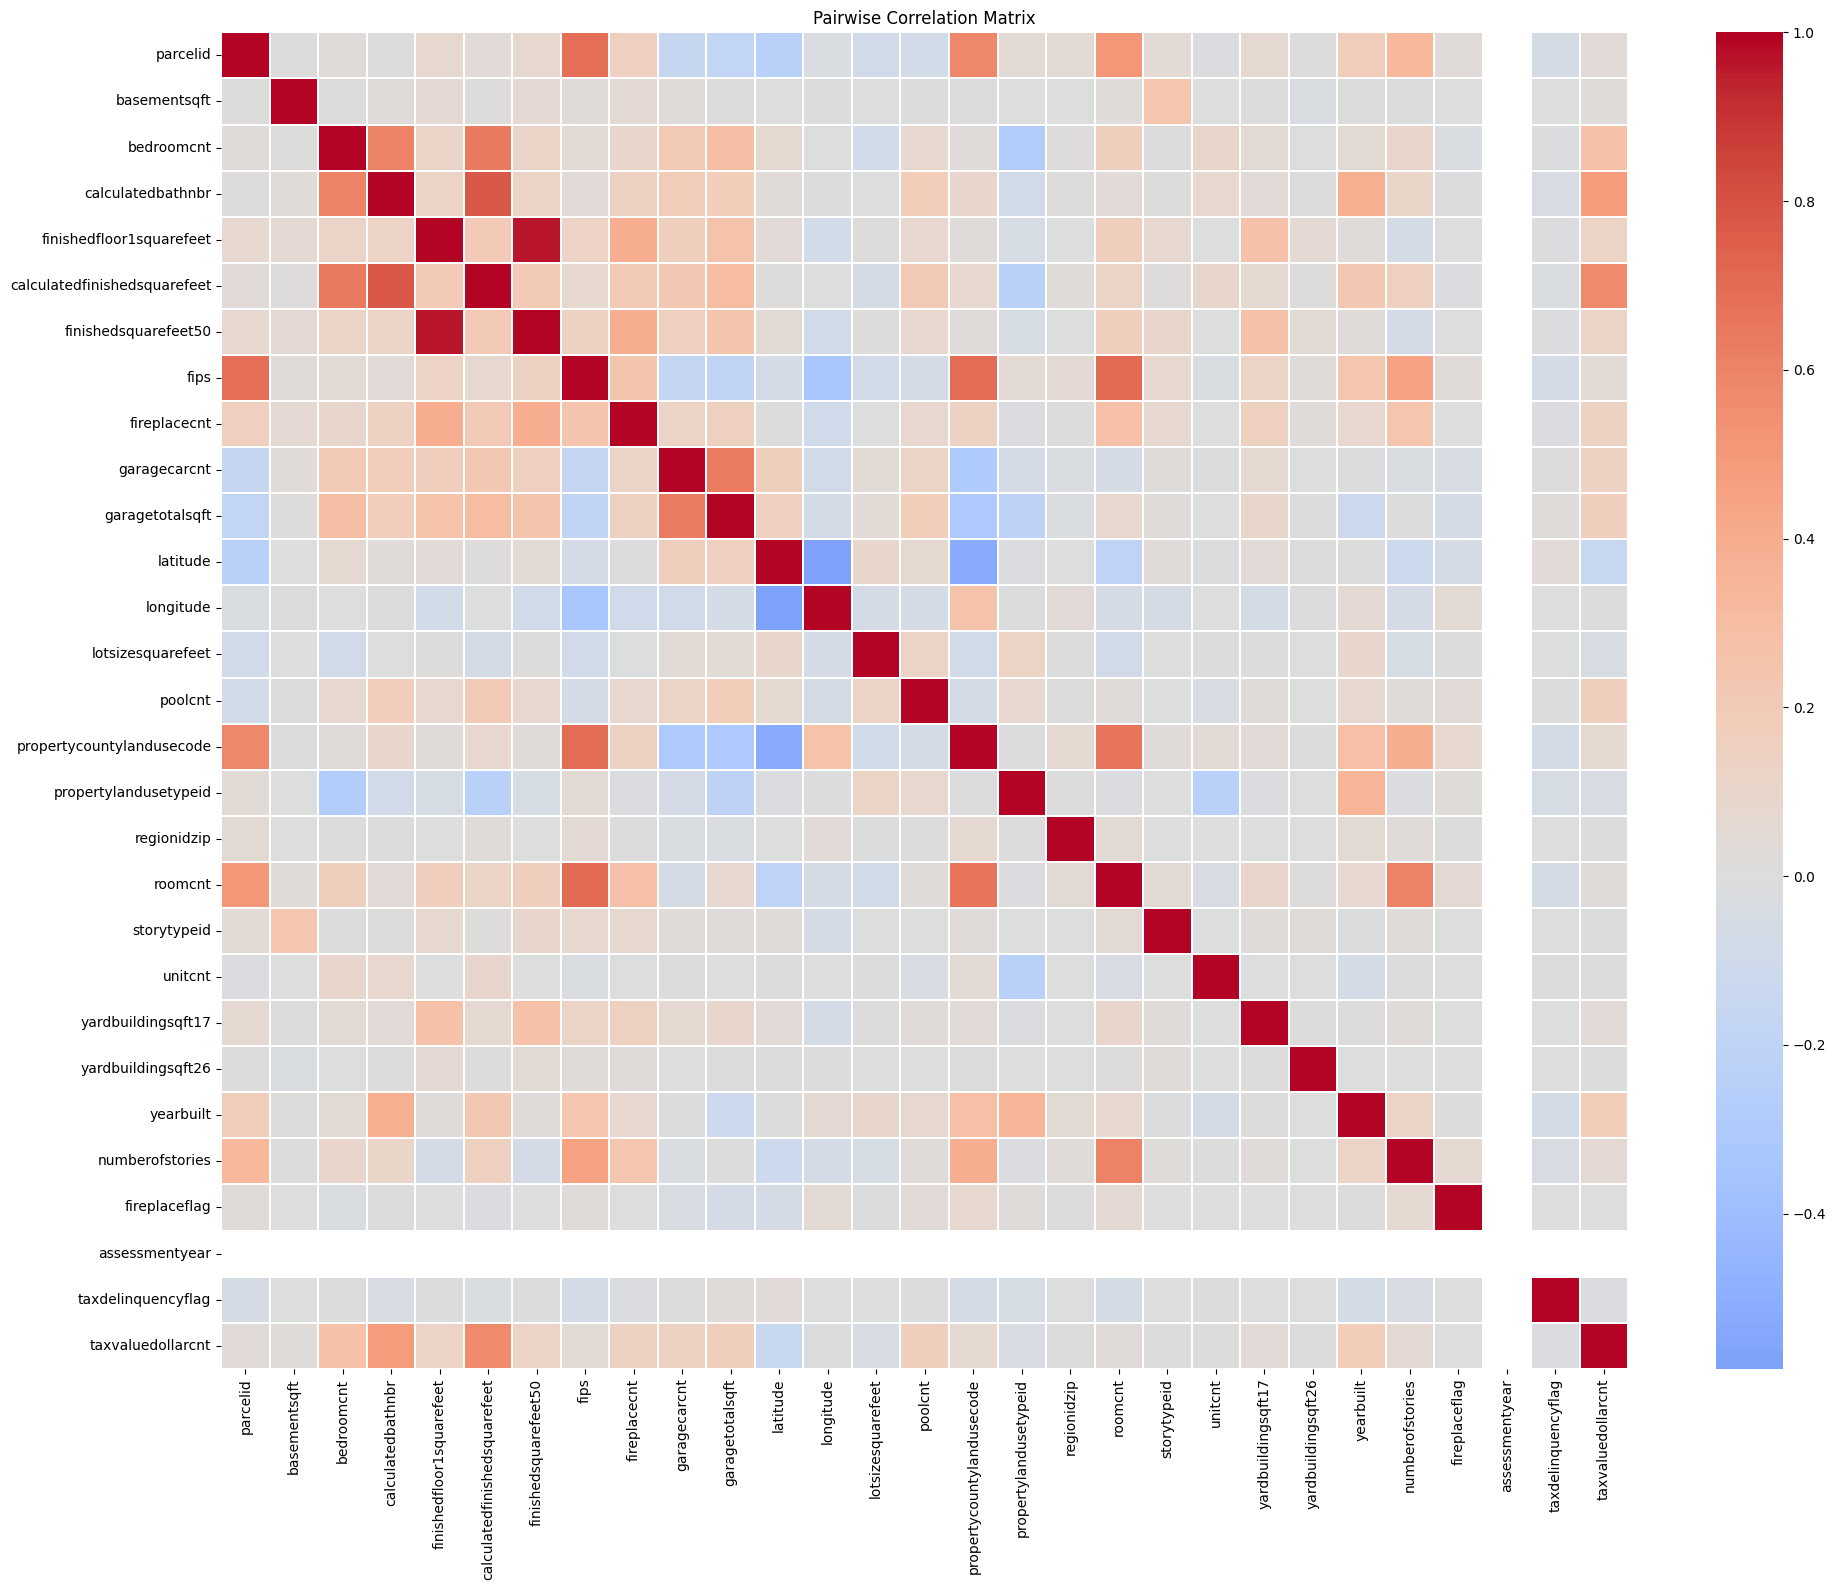

In [6]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Pairwise Correlation Matrix")
plt.tight_layout()
plt.show()

In [7]:
# Correlation with the target, sorted
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlation with target:")
print(target_corr)

Correlation with target:
calculatedfinishedsquarefeet    0.569621
calculatedbathnbr               0.480845
bedroomcnt                      0.264334
yearbuilt                       0.177641
garagetotalsqft                 0.165399
poolcnt                         0.165240
fireplacecnt                    0.144532
garagecarcnt                    0.142327
finishedsquarefeet50            0.123425
finishedfloor1squarefeet        0.122909
propertycountylandusecode       0.070750
numberofstories                 0.057936
fips                            0.046683
yardbuildingsqft17              0.038289
parcelid                        0.035374
roomcnt                         0.030368
basementsqft                    0.018213
unitcnt                         0.012681
storytypeid                     0.009152
yardbuildingsqft26              0.008897
regionidzip                     0.006488
fireplaceflag                  -0.007124
longitude                      -0.011471
taxdelinquencyflag             -

## 2. F-Statistic (f_regression)

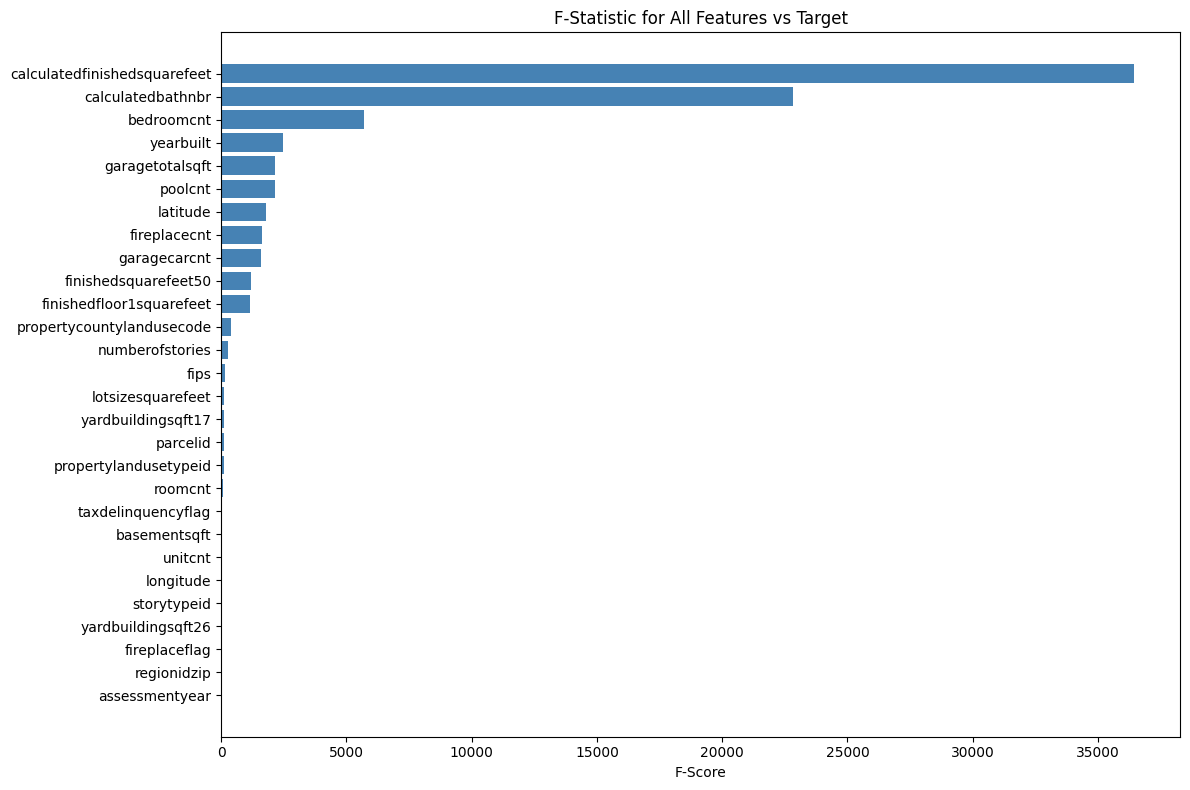

,feature,f_score,p_value
0,calculatedfinishedsquarefeet,36452.014876,0.000000e+00
1,calculatedbathnbr,22824.355489,0.000000e+00
2,bedroomcnt,5701.095608,0.000000e+00
3,yearbuilt,2472.912628,0.000000e+00
4,garagetotalsqft,2134.555313,0.000000e+00
5,poolcnt,2130.352984,0.000000e+00
6,latitude,1803.574918,0.000000e+00
7,fireplacecnt,1619.168140,0.000000e+00
8,garagecarcnt,1569.129525,0.000000e+00
9,finishedsquarefeet50,1174.008034,2.450158e-255


In [8]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({"feature": X.columns, "f_score": f_scores, "p_value": p_values})
f_df = f_df.sort_values("f_score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 8))
plt.barh(f_df["feature"], f_df["f_score"], color="steelblue")
plt.xlabel("F-Score")
plt.title("F-Statistic for All Features vs Target")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

f_df.head(15)

## 3. Forward and Backward Feature Selection

Using `SequentialFeatureSelector` with a simple `LinearRegression` estimator.
Adjust `n_features_to_select` as appropriate.

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #z score scaling

estimator = RandomForestRegressor(random_state=42)
n_select = 3  # TODO: adjust

# Forward selection
sfs_forward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="forward", cv=3, scoring="neg_mean_squared_error"
)
sfs_forward.fit(X_scaled, y)
forward_features = X.columns[sfs_forward.get_support()].tolist()
print(f"Forward selection ({n_select}): {forward_features}")

Forward selection (3): ['calculatedbathnbr', 'propertylandusetypeid', 'regionidzip']


In [15]:
# Backward selection
sfs_backward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="backward", cv=3, scoring="r2"
)
sfs_backward.fit(X_scaled, y)
backward_features = X.columns[sfs_backward.get_support()].tolist()
print(f"Backward selection ({n_select}): {backward_features}")

Backward selection (6): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'roomcnt']


In [16]:
# Compare the two methods
common = set(forward_features) & set(backward_features)
only_forward = set(forward_features) - set(backward_features)
only_backward = set(backward_features) - set(forward_features)

print(f"Common to both:  {common}")
print(f"Only forward:    {only_forward}")
print(f"Only backward:   {only_backward}")

Common to both:  {'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'longitude', 'latitude', 'bedroomcnt'}
Only forward:    {'propertycountylandusecode'}
Only backward:   {'roomcnt'}


---
## Discussion 4.A

Describe what you see in the feature relationships and correlations:
- Strongly correlated feature pairs?
- Do correlation, F-statistic, and SFS methods agree or disagree?
- Any surprises?

*Many of the variables that have a high correlation expected. House values, and therefore tax values, rely on the common square feet, beds, bath, and lot size. It is not suprising that these values are highly correlated with each other and the target. 

The suprise lie in the parcelid and fips being highly correlated. They seemed to both be different identifiers but it is unusal that they are related to each other. 

It is sensible that a model would be able to use the combiantion of latitude and longitude to better predict a tax value. It is a little surprising to see in the F-Stastic that they have very different F-values. *

---
### Next Notebook → `05_bivariate_analysis.ipynb`